**Gradient for logistic regression** — despite the cost function being completely different from linear regression (log loss vs. squared error), the gradient formulas end up having the **exact same form**:

$$\frac{\partial J(\mathbf{w},b)}{\partial w_j} = \frac{1}{m}\sum_{i=0}^{m-1}\big(f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)}\big)x_j^{(i)} \qquad \frac{\partial J(\mathbf{w},b)}{\partial b} = \frac{1}{m}\sum_{i=0}^{m-1}\big(f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)}\big)$$

The only difference from linear regression's gradient: $f_{\mathbf{w},b}(\mathbf{x}^{(i)})$ here means the **sigmoid** output $g(\mathbf{w}\cdot\mathbf{x}^{(i)}+b)$, not the raw linear combination. This is why `compute_gradient_logistic` below looks almost identical to the multi-feature linear regression `compute_gradient` from earlier in this conversation — same structure, one extra `sigmoid()` call.

**Walking through the nested loops** — same two-loop pattern as multi-feature linear regression's gradient:
- **Outer loop (`i`)**: goes example by example. For each example, computes `f_wb_i` (sigmoid prediction) and `err_i` (the error term, shared across all features for this example).
- **Inner loop (`j`)**: goes feature by feature *within* that example, multiplying the shared `err_i` by that feature's value `X[i,j]` and accumulating into `dj_dw[j]`.

`np.zeros((n,))` initializes one accumulator slot per feature — same reasoning as the linear regression version: each feature needs its own independent running total.

In [2]:
import numpy as np
import copy
import math
import matplotlib.pyplot as plt

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def compute_gradient_logistic(X, y, w, b): 
    """
    Computes the gradient for logistic regression 
    Args:
      X (ndarray (m,n): Data, m examples with n features
      y (ndarray (m,)): target values
      w (ndarray (n,)): model parameters  
      b (scalar)      : model parameter
    Returns
      dj_dw (ndarray (n,)): The gradient of the cost w.r.t. the parameters w. 
      dj_db (scalar)      : The gradient of the cost w.r.t. the parameter b. 
    """
    m,n = X.shape
    dj_dw = np.zeros((n,))                           #(n,)
    dj_db = 0.
    for i in range(m):
        f_wb_i = sigmoid(np.dot(X[i],w) + b)          #(n,)(n,)=scalar
        err_i  = f_wb_i  - y[i]                       #scalar
        for j in range(n):
            dj_dw[j] = dj_dw[j] + err_i * X[i,j]      #scalar
        dj_db = dj_db + err_i
    dj_dw = dj_dw/m                                   #(n,)
    dj_db = dj_db/m                                   #scalar
        
    return dj_db, dj_dw

**Structurally identical to linear regression's `gradient_descent`** from earlier — same simultaneous update, same cost-history tracking, same periodic print logic. The only change: it calls `compute_gradient_logistic` and `compute_cost_logistic` instead of the linear regression versions. This is worth noticing directly — gradient descent as an *algorithm* doesn't care what cost function you're minimizing; it just needs a gradient function and a cost function with matching signatures.

In [3]:
def compute_cost_logistic(X, y, w, b):
    m = X.shape[0]
    cost = 0.0
    for i in range(m):
        z_i = np.dot(X[i], w) + b
        f_wb_i = sigmoid(z_i)
        cost += -y[i]*np.log(f_wb_i) - (1-y[i])*np.log(1-f_wb_i)
    cost = cost / m
    return cost

def gradient_descent(X, y, w_in, b_in, alpha, num_iters): 
    """
    Performs batch gradient descent
    Args:
      X (ndarray (m,n))   : Data, m examples with n features
      y (ndarray (m,))    : target values
      w_in (ndarray (n,)) : Initial values of model parameters  
      b_in (scalar)       : Initial values of model parameter
      alpha (float)       : Learning rate
      num_iters (scalar)  : number of iterations to run gradient descent
    Returns:
      w (ndarray (n,))    : Updated values of parameters
      b (scalar)          : Updated value of parameter 
    """
    J_history = []
    w = copy.deepcopy(w_in)
    b = b_in
    
    for i in range(num_iters):
        dj_db, dj_dw = compute_gradient_logistic(X, y, w, b)   
        w = w - alpha * dj_dw               
        b = b - alpha * dj_db               
      
        if i<100000:
            J_history.append( compute_cost_logistic(X, y, w, b) )
        if i% math.ceil(num_iters / 10) == 0:
            print(f"Iteration {i:4d}: Cost {J_history[-1]}   ")
        
    return w, b, J_history

Using the Breast Cancer Wisconsin dataset again (same one as your earlier sklearn comparison), so you can cross-check this manual implementation's results against `LogisticRegression()` from before if you want.

In [4]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

data = load_breast_cancer()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

n_features = X_train_scaled.shape[1]
w_init = np.zeros(n_features)
b_init = 0.0

w_final, b_final, J_history = gradient_descent(X_train_scaled, y_train, w_init, b_init, alpha=0.1, num_iters=1000)

Iteration    0: Cost 0.5164481705931235   
Iteration  100: Cost 0.10016431429716918   
Iteration  200: Cost 0.08293899326832485   
Iteration  300: Cost 0.0753767179064828   
Iteration  400: Cost 0.07085813643245259   
Iteration  500: Cost 0.06775209354337841   
Iteration  600: Cost 0.06543748479208167   
Iteration  700: Cost 0.0636195629458158   
Iteration  800: Cost 0.062137962232402526   
Iteration  900: Cost 0.06089685612417429   


**Why this plot matters** — this is the standard sanity check for any gradient descent run: cost should decrease smoothly and monotonically (or very close to it). If it oscillates or increases, `alpha` is likely too large; if it's still decreasing steeply at the end, `num_iters` may be too low.

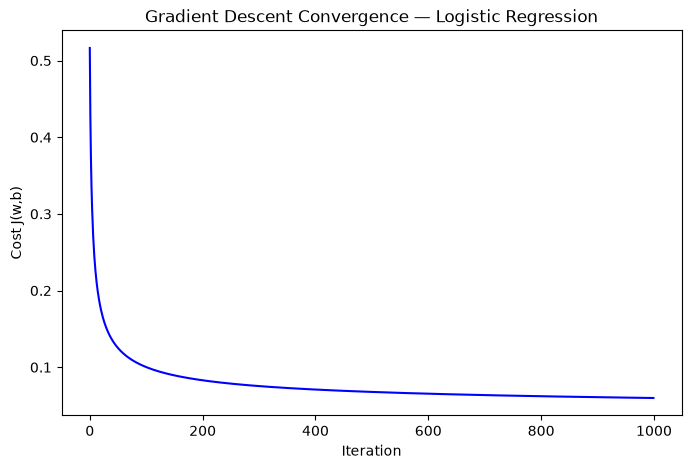

In [5]:
plt.figure(figsize=(8, 5))
plt.plot(J_history, color='blue')
plt.xlabel('Iteration')
plt.ylabel('Cost J(w,b)')
plt.title('Gradient Descent Convergence — Logistic Regression')
plt.show()

Reusing `ConfusionMatrixDisplay` from your earlier sklearn comparison — same visualization, now applied to your from-scratch model's predictions.

Manual gradient descent (n=30 features) — test accuracy: 0.974


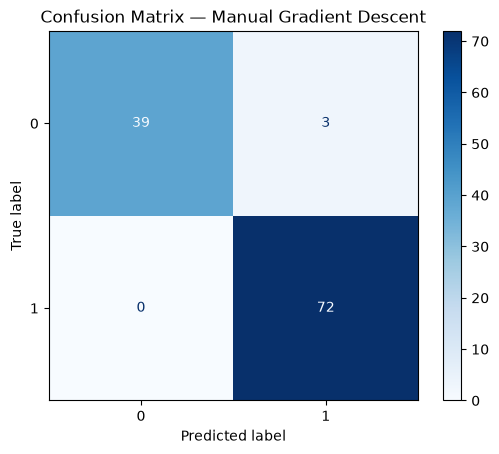

In [6]:
from sklearn.metrics import ConfusionMatrixDisplay

z_test = X_test_scaled @ w_final + b_final
proba_test = sigmoid(z_test)
pred_test = (proba_test >= 0.5).astype(int)

accuracy = np.mean(pred_test == y_test)
print(f"Manual gradient descent (n={n_features} features) — test accuracy: {accuracy:.3f}")

ConfusionMatrixDisplay.from_predictions(y_test, pred_test, cmap='Blues')
plt.title('Confusion Matrix — Manual Gradient Descent')
plt.show()